<a href="https://colab.research.google.com/github/SMcod/Assignment-3/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost kagglehub

In [ ]:
#Import necessary libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
### Our dataset was too large, so drive is blocking the direct download

from google.colab import files
uploaded = files.upload()

Saving mercedes_benz_sales_2020_2025.csv to mercedes_benz_sales_2020_2025.csv


In [ ]:
#Loading Data Set

In [ ]:
### Load the dataset
import pandas as pd

data = pd.read_csv("/content/mercedes_benz_sales_2020_2025.csv", low_memory=False)

### Using smaller dataset for faster training
data = data.sample(n=50000, random_state=42)

data.head()

,Model,Year,Region,Color,Fuel Type,Base Price (USD),Horsepower,Sales Volume,Turbo
1398901,GLC,2020,Global,White,Petrol,115617.0,261.0,1.0,Yes
514336,E-Class,2020,Global,Silver,Petrol,82164.0,423.0,1.0,Yes
432337,C-Class,2020,Global,Black,Petrol,77225.0,318.0,1.0,Yes
741083,CLA,2020,Global,Black,Petrol,42085.0,397.0,1.0,Yes
1779151,A-Class,2021,Global,Black,Diesel,58268.0,204.0,1.0,Yes


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 1398901 to 1099889
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Model             50000 non-null  object 
 1   Year              50000 non-null  int64  
 2   Region            50000 non-null  object 
 3   Color             50000 non-null  object 
 4   Fuel Type         50000 non-null  object 
 5   Base Price (USD)  50000 non-null  float64
 6   Horsepower        50000 non-null  float64
 7   Sales Volume      50000 non-null  float64
 8   Turbo             50000 non-null  object 
dtypes: float64(3), int64(1), object(5)
memory usage: 3.8+ MB


In [ ]:
print(data.columns)

Index(['Model', 'Year', 'Region', 'Color', 'Fuel Type', 'Base Price (USD)',
       'Horsepower', 'Sales Volume', 'Turbo'],
      dtype='object')


In [ ]:
data.describe()

,Year,Base Price (USD),Horsepower,Sales Volume
count,50000.000000,50000.000000,50000.000000,50000.0
mean,2020.084520,92935.180840,360.298180,1.0
std,0.278169,59871.089504,118.329515,0.0
min,2020.000000,35003.000000,150.000000,1.0
25%,2020.000000,57555.750000,269.000000,1.0
50%,2020.000000,75437.500000,351.000000,1.0
75%,2020.000000,103207.250000,432.000000,1.0
max,2021.000000,349937.000000,831.000000,1.0


In [ ]:
print(data.isnull().sum())

Model               0
Year                0
Region              0
Color               0
Fuel Type           0
Base Price (USD)    0
Horsepower          0
Sales Volume        0
Turbo               0
dtype: int64


In [ ]:
print(data.duplicated().sum())

2


In [ ]:
data = data.drop_duplicates()

In [ ]:
4. #Basic Visualizations (EDA)

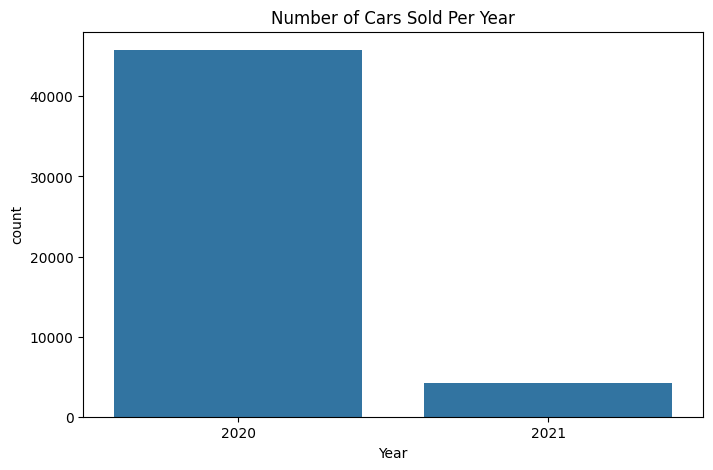

In [ ]:
### Sales per year
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x='Year', data=data)
plt.title("Number of Cars Sold Per Year")
plt.show()

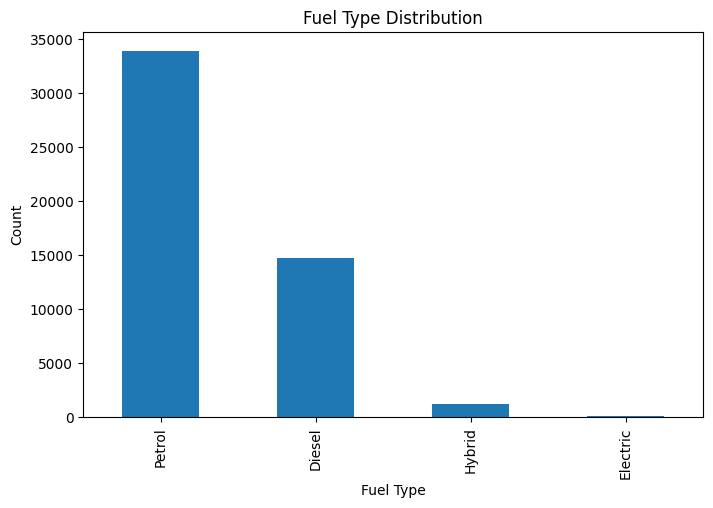

In [ ]:
### Fuel type distribution

plt.figure(figsize=(8,5))
data['Fuel Type'].value_counts().plot(kind='bar')
plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.show()

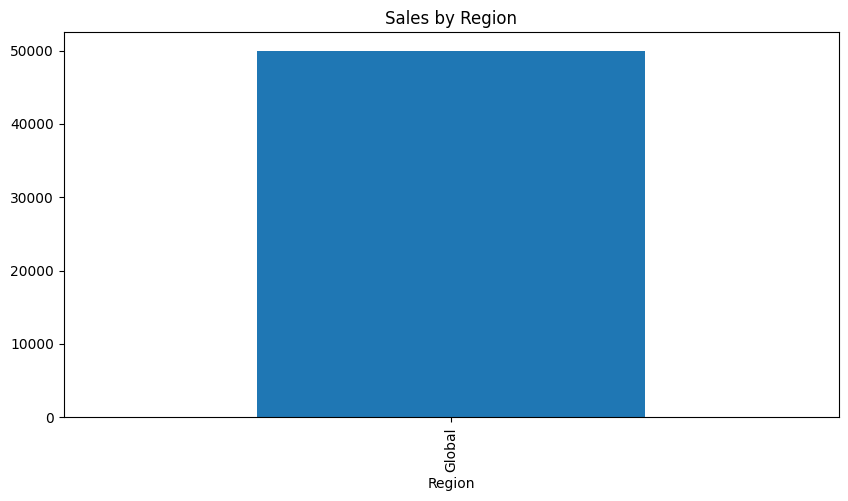

In [ ]:
### Regional sales distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
data['Region'].value_counts().plot(kind='bar')
plt.title("Sales by Region")
plt.show()

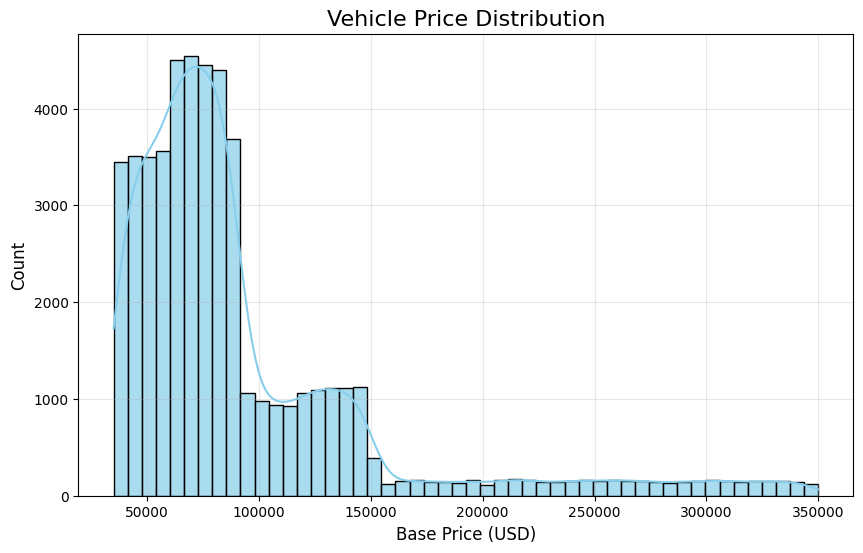

In [ ]:
### Price Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(data['Base Price (USD)'],
             bins=50,
             kde=True,
             color='skyblue',
             edgecolor='black',
             alpha=0.7
)
plt.title("Vehicle Price Distribution", fontsize=16)
plt.xlabel("Base Price (USD)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
#Data Processing

In [ ]:
### checking which columns are categorical

print(data.select_dtypes(include='object').columns)

Index(['Model', 'Region', 'Color', 'Fuel Type', 'Turbo'], dtype='object')


In [ ]:
## encoding categorical variables
import pandas as pd
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col])

In [ ]:
#Feature selection

In [ ]:
### Choosing target variable: whether a car has turbo or not

X = data.drop("Turbo", axis=1)
y = data["Turbo"]



## ask chat how to run this

In [ ]:
#Train Test Split

In [ ]:
### splitting the dataset into training and testing sets
import pandas as pd
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
8. #Train Machine Learning Models

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression(max_iter=1000, random_state=0)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

In [ ]:
### Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [ ]:
#Evaluate the model

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall:", recall_score(y_test, rf_pred))
print("F1 Score:", f1_score(y_test, rf_pred))

Accuracy: 0.8333
Precision: 0.8499231163505895
Recall: 0.9761007770190723
F1 Score: 0.9086525289056935


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, rf_pred)
print(cm)

[[  42 1464]
 [ 203 8291]]


In [ ]:
#Extracting FN TN PN PT

In [ ]:
tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

True Negatives: 42
False Positives: 1464
False Negatives: 203
True Positives: 8291


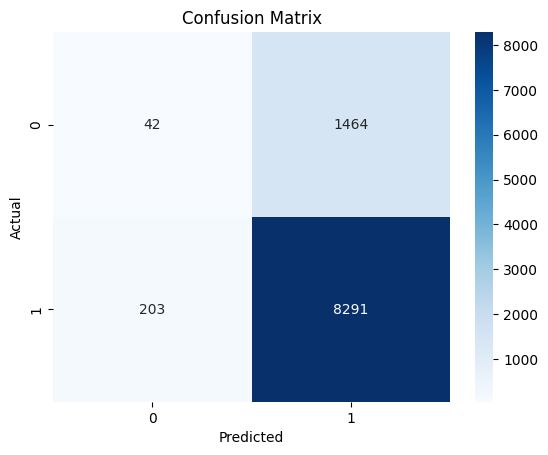

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.15      0.16      0.15      1506
           1       0.85      0.84      0.84      8494

    accuracy                           0.73     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.74      0.73      0.74     10000



In [ ]:
xgb_pred = xgb_clf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

result = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest","Decision Tree"],

    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, dt_pred)
        ],

    "Precision": [precision_score(y_test, lr_pred),
                  precision_score(y_test, rf_pred),
                  precision_score(y_test, dt_pred)
                  ],
    "Recall": [recall_score(y_test, lr_pred),
               recall_score(y_test, rf_pred),
               recall_score(y_test, dt_pred)
               ],
    "F1 Score": [f1_score(y_test, lr_pred),
                 f1_score(y_test, rf_pred),
                 f1_score(y_test, dt_pred)
                 ]
})
print(result)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.8494   0.849400  1.000000  0.918568
1        Random Forest    0.8333   0.849923  0.976101  0.908653
2        Decision Tree    0.7340   0.848590  0.836002  0.842249


In [ ]:
print(result)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression    0.8494   0.849400  1.000000  0.918568
1        Random Forest    0.8333   0.849923  0.976101  0.908653
2        Decision Tree    0.7340   0.848590  0.836002  0.842249


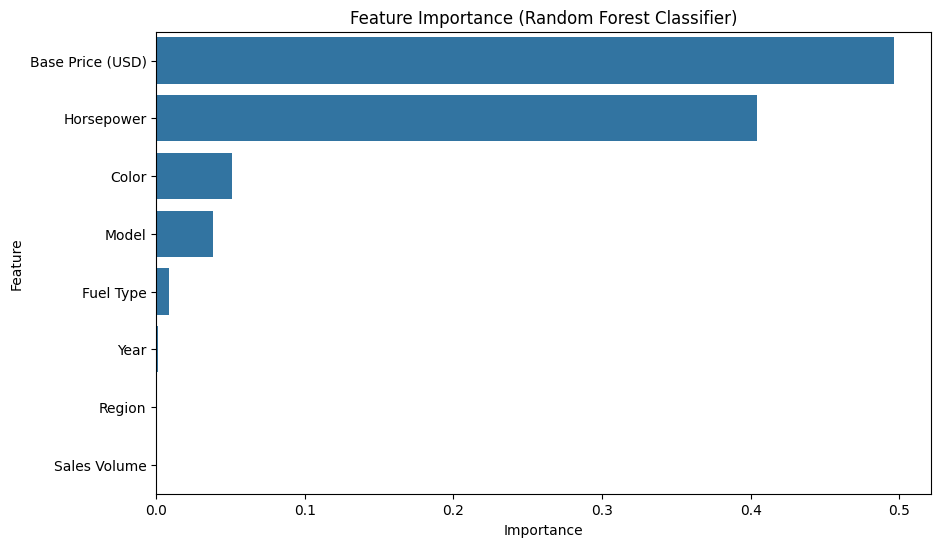

In [ ]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importance = rf.feature_importances_
features = X.columns

importance_data = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=importance_data)
plt.title("Feature Importance (Random Forest Classifier)")
plt.show()

In [ ]:
from xgboost import XGBClassifier
xgb_clf = XGBClassifier(eval_metric='logloss')
xgb_clf.fit(X_train, y_train)

sample = X_test.iloc[0:1]
prediction = xgb_clf.predict(sample)
print("Predicted class:", prediction[0])
proba = xgb_clf.predict_proba(sample)
print("class probabilities:" , proba)

Predicted class: 1
class probabilities: [[0.10188299 0.898117  ]]
